In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

## Part 1

In [ ]:
def read_mesa_profile(filepath):
    df = pd.read_csv(filepath, skiprows=5, delim_whitespace=True)
    return df

file1 = 'LOGS/profile1.data'
file5 = 'LOGS/profile5.data'
file10 = 'LOGS/profile10.data'
file15 = 'LOGS/profile15.data'
file30 = 'LOGS/profile30.data'
file70 = 'LOGS/profile70.data'


df1 = read_mesa_profile(file1)
df5 = read_mesa_profile(file5)
df10 = read_mesa_profile(file10)
df15 = read_mesa_profile(file15)
df30 = read_mesa_profile(file30)
df70 = read_mesa_profile(file70)


def plot_profile(df, label, color):
    N_squared = df['brunt_N2']
    N = np.sqrt(np.maximum(N_squared, 0))
    radius = df['logR']
    plt.plot(radius, N, label=label, color=color, linewidth=2)
    

    core_mask = N > 0
    if core_mask.any():
        core_radius = radius[core_mask].iloc[-1] 
        plt.axvline(x=core_radius, color=color, linestyle=':', alpha=0.7)
        print(fr'[{label}] convection core radius: {core_radius:.4f} $R_\odot$')



[profile1] convection core radius: -0.3123 $R_\odot$
[profile5] convection core radius: -0.4928 $R_\odot$
[profile10] convection core radius: -3.0624 $R_\odot$
[profile15] convection core radius: -1.3841 $R_\odot$
[profile30] convection core radius: -4.2987 $R_\odot$
[profile70] convection core radius: -4.4295 $R_\odot$


/var/folders/3d/zhglhjh956l46r7799k91vhh0000gn/T/ipykernel_73901/1984290227.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')


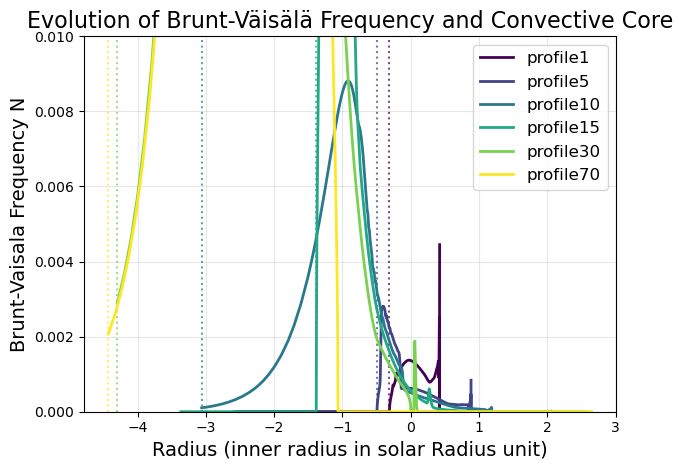

In [ ]:
cmap = cm.get_cmap('viridis')
linspace_values = np.linspace(0, 1, 6) 
colors = cmap(linspace_values)

plot_profile(df1, label='profile1', color=colors[0])
plot_profile(df5, label='profile5', color=colors[1])
plot_profile(df10, label='profile10', color=colors[2])
plot_profile(df15, label='profile15', color=colors[3])
plot_profile(df30, label='profile30', color=colors[4])
plot_profile(df70, label='profile70', color=colors[5])
plt.xlabel('Radius (inner radius in solar Radius unit)', fontsize=14)
plt.ylabel('Brunt-Vaisala Frequency N', fontsize=14)
plt.title('Evolution of Brunt-Väisälä Frequency and Convective Core', fontsize=16)

plt.ylim(0, 0.01) 
plt.xlim(-2,0)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

## Part 2

In [55]:
def calculate_period_spacing(gyre_filepath):
    df = pd.read_csv(gyre_filepath, delim_whitespace=True, skiprows=5)
    df['P'] = 1.0 / df['Re(freq)']

    # l = 1, n<0
    g_modes = df[(df['l'] == 1) & (df['n_pg'] < 0)].copy()
    g_modes = g_modes.sort_values(by='P')
    P = g_modes['P'].values * 24 * 3600 # day -> second
    delta_P = np.diff(P)
    
    mean_dp = np.mean(delta_P)

    return mean_dp, delta_P, P

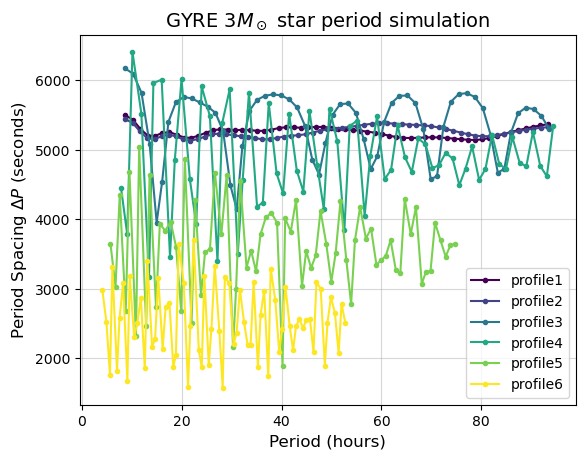

In [56]:
# plot results
result1 = calculate_period_spacing('gyre_out/gyre_summary1.txt')
result2 = calculate_period_spacing('gyre_out/gyre_summary2.txt')
result3 = calculate_period_spacing('gyre_out/gyre_summary3.txt')
result4 = calculate_period_spacing('gyre_out/gyre_summary4.txt')
result5 = calculate_period_spacing('gyre_out/gyre_summary5.txt')
result6 = calculate_period_spacing('gyre_out/gyre_summary6.txt')

results = [result1,result2,result3,result4,result5,result6,]
for i,result in enumerate(results):
    mean,dp,p = result
    plt.plot(p[:-1]/3600,dp, label = f'profile{i+1}',marker='.',color=colors[i])
plt.xlabel('Period (hours)', fontsize=12)
plt.ylabel(r'Period Spacing $\Delta P$ (seconds)', fontsize=12)
plt.title(r'GYRE $3M_\odot$ star period simulation', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()